# "Correlation Between People I Follow and Posts I Like" Data Report - 9/22/26 #

## By Harrison Pittle ## 

##### This data came from Meta and shows which posts I have liked on my "PittFilms" business Instagram account since 2020. Meta keeps track of this data for all Meta accounts in order to offer more targeted advertising to users and for advertisers to learn more about their customers. This data is reliable because it is factual and correct, BUT it is hard to access, confusing to read, and it may not include every post I have ever liked (I don't see data pre-2020).

In [1]:
import json
import pandas as pd

with open('liked_posts.json', 'r') as f:
    data = json.load(f)

data[0]

{'timestamp': 1580214947,
 'media': [],
 'label_values': [{'label': 'URL',
   'value': 'https://www.instagram.com/p/B71bSoGH5sV/',
   'href': 'https://www.instagram.com/p/B71bSoGH5sV/'},
  {'label': 'Caption',
   'value': 'Lost in the Salt with @boyanoo and his #DJI #Mavic2Pro.'},
  {'label': 'Title', 'value': ''},
  {'dict': [{'dict': [{'label': 'Name', 'value': 'mavic2pro'}], 'title': ''},
    {'dict': [{'label': 'Name', 'value': 'dji'}], 'title': ''}],
   'title': 'Hashtags'},
  {'dict': [{'dict': [{'label': 'URL', 'value': 'https://brnw.ch/21x2iC0'},
      {'label': 'Name', 'value': 'DJI'},
      {'label': 'Username', 'value': 'djiglobal'}],
     'title': ''}],
   'title': 'Owner'},
  {'dict': [], 'title': 'Brand partner'}],
 'fbid': '17875175812543297'}

In [2]:
row = {}
row['timestamp'] = data[0]['timestamp']

row

{'timestamp': 1580214947}

In [3]:
for item in data[0]['label_values']:
    if 'label' in item:
        row[item['label']] = item['value']

row

{'timestamp': 1580214947,
 'URL': 'https://www.instagram.com/p/B71bSoGH5sV/',
 'Caption': 'Lost in the Salt with @boyanoo and his #DJI #Mavic2Pro.',
 'Title': ''}

In [4]:
for item in data[0]['label_values']:
    if 'label' in item:
        row[item['label']] = item['value']
    elif item.get('title') == 'Owner':
        owner_fields = item['dict'][0]['dict']
        for owner_item in owner_fields:
            row['Owner' + owner_item['label']] = owner_item['value']

row

{'timestamp': 1580214947,
 'URL': 'https://www.instagram.com/p/B71bSoGH5sV/',
 'Caption': 'Lost in the Salt with @boyanoo and his #DJI #Mavic2Pro.',
 'Title': '',
 'OwnerURL': 'https://brnw.ch/21x2iC0',
 'OwnerName': 'DJI',
 'OwnerUsername': 'djiglobal'}

In [5]:
tidy_rows = []

for entry in data:
    row = {}
    row['timestamp'] = entry['timestamp']
    
    for item in entry['label_values']:
        if 'label' in item:
            row[item['label']] = item['value']
        elif item.get('title') == 'Owner':
            owner_fields = item['dict'][0]['dict']
            for owner_item in owner_fields:
                row['Owner' + owner_item['label']] = owner_item['value']
    tidy_rows.append(row)

tidy_rows[:2]

[{'timestamp': 1580214947,
  'URL': 'https://www.instagram.com/p/B71bSoGH5sV/',
  'Caption': 'Lost in the Salt with @boyanoo and his #DJI #Mavic2Pro.',
  'Title': '',
  'OwnerURL': 'https://brnw.ch/21x2iC0',
  'OwnerName': 'DJI',
  'OwnerUsername': 'djiglobal'},
 {'timestamp': 1580214917,
  'URL': 'https://www.instagram.com/p/B71A3Pqga3I/',
  'Caption': "Ok, I know she's angry about something. I just don't know what it is I did exactly. ð\x9f\x98\x95 \n#burrowingowl #owls #wildlifephotography #owl #wildlife #birds #bird #birdphotography #birdwatching #birding #gecko",
  'Title': '',
  'OwnerURL': 'http://geico.com',
  'OwnerName': 'The GEICO Gecko, Azzi Fudd Fanatic',
  'OwnerUsername': 'thegeicogecko'}]

In [6]:
likes_df = pd.DataFrame(tidy_rows)
likes_df.head(10)

,timestamp,URL,Caption,Title,OwnerURL,OwnerName,OwnerUsername
0,1580214947,https://www.instagram.com/p/B71bSoGH5sV/,Lost in the Salt with @boyanoo and his #DJI #M...,,https://brnw.ch/21x2iC0,DJI,djiglobal
1,1580214917,https://www.instagram.com/p/B71A3Pqga3I/,"Ok, I know she's angry about something. I just...",,http://geico.com,"The GEICO Gecko, Azzi Fudd Fanatic",thegeicogecko
2,1580214905,https://www.instagram.com/p/B72vavJlMIs/,The Mt. Lebanon boys varsity basketball team s...,,,Harrison Lilley,hlilleymedia
3,1580214895,https://www.instagram.com/p/B72sx5KlP9V/,Mt. Lebanon girls basketball coach Carl Satira...,,,Harrison Lilley,hlilleymedia
4,1580214873,https://www.instagram.com/p/B71JCW1HT2I/,Motivation Monday ð¤ð¼5 month build from j...,,https://linktr.ee/tacomabeast,tacomabeast,tacomabeast
5,1580214863,https://www.instagram.com/tv/B70zxSwpikM/,#Gunfight #Nerf #KidsStuff,Mission Accomplished,http://www.amazon.com/dp/1732138702/ref=cm_sw_...,David Alan Arnold,airbornecamera
6,1580214835,https://www.instagram.com/p/B71sNB0FwaU/,Wooden Camera offers 3 levels of accessory kit...,,https://sprout.link/woodencamera,Wooden Camera | Creative Solutions,woodencamera
7,1580214834,https://www.instagram.com/p/B71xkwHpIWv/,SO ready to photograph this couples wedding th...,,http://www.samcortphoto.com/,Wedding Videographer,samcortphoto
8,1580214805,https://www.instagram.com/p/B72sdF8FjLl/,A Peters Township boys varsity basketball play...,,,Harrison Lilley,hlilleymedia
9,1580209636,https://www.instagram.com/p/B71Zy51pwRJ/,"SensaciÃ³n tÃ©rmica 40 grados, temperatura rea...",,https://www.imdb.com/es-es/name/nm0881943/?ref...,Vitoco Uribe,kukofilms


In [7]:
likes_df['DateTime'] = pd.to_datetime(likes_df['timestamp'], unit = 's')
likes_df[['timestamp', 'DateTime']].head()

,timestamp,DateTime
0,1580214947,2020-01-28 12:35:47
1,1580214917,2020-01-28 12:35:17
2,1580214905,2020-01-28 12:35:05
3,1580214895,2020-01-28 12:34:55
4,1580214873,2020-01-28 12:34:33


In [8]:
likes_df.shape

(49788, 8)

In [9]:
likes_df['OwnerUsername'].isna().sum()

np.int64(0)

In [10]:
likes_df.dtypes

timestamp                int64
URL                        str
Caption                    str
Title                      str
OwnerURL                   str
OwnerName                  str
OwnerUsername              str
DateTime         datetime64[s]
dtype: object

In [11]:
likes_by_account = (
    likes_df.groupby("OwnerUsername")["DateTime"]
    .count()
    .sort_values(ascending=False)
)
likes_by_account.head(10)

OwnerUsername
motortrend         3534
filmmkrs            706
carsandbids         701
airbornecamera      679
cinematogr          557
usa_ford_ranger     529
iamtamlam           524
itsnickmetzger      502
tacomabeast         448
mkbhd               438
Name: DateTime, dtype: int64

### All code above this point was done in class over several class days. It takes my liked posts Instagram data and visualizes it in a table that shows which accounts I have liked the most posts of. ###

# My hypothesis: The majority (>50%) of posts I like were created by users that I already follow. I can test this using my following data. This would be interesting and important for advertisers to know that I am more likely to like posts from users I already follow. This can be used to make more targeted advertising, such as Sony Cameras giving me more ads because I already follow them.

In [12]:


with open('following_copy.json', 'r') as g:
    following_data = json.load(g)



In [13]:
type(following_data)

dict

In [14]:
pd.DataFrame(following_data)

,relationships_following
0,"{'title': 'daviflan', 'string_list_data': [{'h..."
1,"{'title': 'shotbybeasley', 'string_list_data':..."
2,"{'title': 'overboard126', 'string_list_data': ..."
3,"{'title': 'katiewaggle', 'string_list_data': [..."
4,"{'title': 'grac.eadams03', 'string_list_data':..."
...,...
4443,"{'title': 'justinboch', 'string_list_data': [{..."
4444,"{'title': 'cal.mcadams', 'string_list_data': [..."
4445,"{'title': 'myermarko73', 'string_list_data': [..."
4446,"{'title': 'awesolowski39', 'string_list_data':..."


#### After importing my following data, I found that the only information I needed to prove my hypothesis was the username data. ####

In [15]:
print(following_data['relationships_following'][0])

{'title': 'daviflan', 'string_list_data': [{'href': 'https://www.instagram.com/_u/daviflan', 'timestamp': 1788137772}]}


In [16]:
following_usernames = [
    entry['string_list_data'][0]['href'].split('/_u/')[-1]
    for entry in following_data['relationships_following']
]

df_following = pd.DataFrame(following_usernames, columns=['Username'])
df_following

,Username
0,daviflan
1,shotbybeasley
2,overboard126
3,katiewaggle
4,grac.eadams03
...,...
4443,justinboch
4444,cal.mcadams
4445,myermarko73
4446,awesolowski39


### The table above lists out the usernames of all 4000+ people that I follow on instagram. Next, I needed to see where those usernames overlapped with the usernames of posts I liked. ###

In [17]:
overlap = pd.merge(
    df_following, likes_df,
    left_on='Username', right_on='OwnerUsername',
    how='inner'
).drop_duplicates()

print(f"Number of overlapping usernames: {len(overlap)}")
overlap

Number of overlapping usernames: 39485


,Username,timestamp,URL,Caption,Title,OwnerURL,OwnerName,OwnerUsername,DateTime
0,daviflan,1788137769,https://www.instagram.com/p/DcraovHli2c/,NaN,NaN,https://www.davisflanneryphoto.com/columbus-crew,Daviflan,daviflan,2026-08-31 00:56:09
1,daviflan,1786885470,https://www.instagram.com/p/DcESlvOFjvD/,NaN,NaN,https://www.davisflanneryphoto.com/columbus-crew,Daviflan,daviflan,2026-08-16 13:04:30
2,ksu_studentmedia,1788204135,https://www.instagram.com/p/DctgpuXEX1S/,Vinny Sainato has been working with Student Me...,,https://linktr.ee/ksustudentmedia,Kent State Student Media,ksu_studentmedia,2026-08-31 19:22:15
3,ksu_studentmedia,1787875641,https://www.instagram.com/p/DckB5VVgCwK/,Sneak peak at The Playbooks 2nd Launch Party\n...,,https://linktr.ee/ksustudentmedia,Kent State Student Media,ksu_studentmedia,2026-08-28 00:07:21
4,kentstatefootballdocumentary,1787875186,https://www.instagram.com/reel/Dcj_FjgOMV6/,Get ready for this upcoming film from Harrison...,,,Kent State Football Documentary,kentstatefootballdocumentary,2026-08-27 23:59:46
...,...,...,...,...,...,...,...,...,...
39480,myermarko73,1719189991,https://www.instagram.com/p/C8lCoEOMx0R/,Well I may be allergic to Nettle,,,Myer,myermarko73,2024-06-24 00:46:31
39481,myermarko73,1714659561,https://www.instagram.com/p/C6d_HwhrAIS/,And Iâd rather do this than go back to schoo...,,,Myer,myermarko73,2024-05-02 14:19:21
39482,connergebben,1570369838,https://www.instagram.com/p/B3R15jnlFKddJC25PY...,Homecoming 2k19,,,Conner Gebben,connergebben,2019-10-06 13:50:38
39483,connergebben,1648746940,https://www.instagram.com/p/CbwFEoOsowM42A1oK8...,Twisted black metal maniacs have\nNO FUN\nNO C...,,,Conner Gebben,connergebben,2022-03-31 17:15:40


In [22]:
likes_df['FromFollowedAccount'] = likes_df['OwnerUsername'].isin(df_following['Username'])

summary = likes_df['FromFollowedAccount'].value_counts().rename(
    index={True: 'Liked Post From Followed Account', False: 'Liked Post From Non-Followed Account'}
).rename_axis('Category').reset_index(name='Count')

summary

,Category,Count
0,Liked Post From Followed Account,39485
1,Liked Post From Non-Followed Account,10303


### My hypothesis asked about percentage of likes from followers vs. non-followers, so I had to convert these numbers into percentages of my total likes over time ###

In [23]:
summary['Percentage'] = (summary['Count'] / summary['Count'].sum() * 100).round(1)
summary

,Category,Count,Percentage
0,Liked Post From Followed Account,39485,79.3
1,Liked Post From Non-Followed Account,10303,20.7


### Finally, to properly display these percentages in a visual diagram, I used a pie chart ###

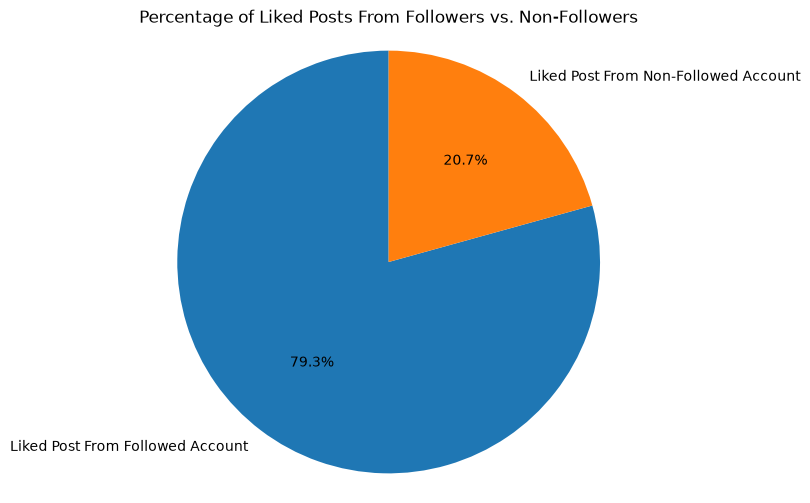

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.pie(
    summary['Count'],
    labels=summary['Category'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Percentage of Liked Posts From Followers vs. Non-Followers')
plt.axis('equal') 
plt.show()

## In conclusion, my hypothesis was correct. A vast majority of my liked posts were created by users that I follow. The data is limited by the timespan that it covers. It did not seem to have any data pre-2020 for my liked posts and will not continue to update past the date I downloaded the data in early-September. In the future, I could simplify the coding process from what we did in class and figure out a way for the data to be updated at a set frequency (weekly, monthly, etc). ##